In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle
# 원핫인코더
from sklearn.preprocessing import OneHotEncoder

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [3]:
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 프로젝트 셋팅

In [6]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/model/best_model2_cde.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [7]:
# 데이터 준비.
# AB와 CDE데이터를 따로 모델링을 해줘야한다
# 그러므로 AB와 CDE의 Train데이터를 따로 준비해야한다.
# Train 말고 Test는 동시에 존재하지만 이것 역시 따로 학습시켜야하니 AB데이터의컬럼, CDE데이터의 컬럼별로 분리시켜준다.
# target 데이터의 경우 AB와 CDE에 Segment가 있는데 이걸 CDE만 떼서 준비한다.

cde_train_df = pd.read_parquet('/content/drive/MyDrive/abcde/cde_train_vif&clustering.parquet')

test_df = pd.read_parquet('/content/drive/MyDrive/abcde/ab_cde_test44.parquet')
# test_df를 ab_train_df와 cd_train_df 각각의 컬럼에 맞춰 두개로 나눈다.

# CDE 분리
cde_cols = cde_train_df.columns

# 'Segment'컬럼은 타겟이라서 test_df에 없어도 됨
missing_cde_cols = [col for col in cde_cols if col != 'Segment' and col not in test_df.columns]

if missing_cde_cols:
    print(f"Warning: test_df에 ab_cols 중 누락된 컬럼이 있습니다: {missing_cde_cols}")

# cd_test_df 생성
cde_test_df = test_df[cde_cols.drop('Segment')]

# target 데이터의 경우 AB와 CDE에 Segment가 있는데 이걸 각각 떼서 준비한다.
cde_target_df = cde_train_df[['ID','기준년월','Segment']]

In [8]:
cde_target_df

,ID,기준년월,Segment
0,TRAIN_000000,201807,D
1,TRAIN_000001,201807,E
2,TRAIN_000002,201807,C
3,TRAIN_000003,201807,D
4,TRAIN_000004,201807,E
...,...,...,...
2398879,TRAIN_399995,201812,E
2398880,TRAIN_399996,201812,D
2398881,TRAIN_399997,201812,C
2398882,TRAIN_399998,201812,E


In [9]:
# 데이터 프레임을 합친다.
all_df = pd.concat([cde_train_df, cde_test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,ID,기준년월,Segment,이용금액_R3M_신용체크,청구금액_R6M,이용카드수_신용체크,_1순위카드이용건수,_2순위카드이용건수,이용금액대,인입횟수_ARS_R6M,방문횟수_앱_R6M,방문횟수_PC_R6M
0,TRAIN_000000,201807,D,196,88693,1,26,0,01.100만원+,10회 이상,1회 이상,1회 이상
1,TRAIN_000001,201807,E,13475,16861,1,46,0,03.30만원+,1회 이상,1회 이상,1회 이상
2,TRAIN_000002,201807,C,23988,165221,1,28,0,01.100만원+,1회 이상,30회 이상,10회 이상
3,TRAIN_000003,201807,D,3904,127371,1,1,0,01.100만원+,10회 이상,1회 이상,1회 이상
4,TRAIN_000004,201807,E,1190,155,1,-2,0,09.미사용,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...
2998879,TEST_99995,201812,NaN,0,0,0,-2,0,09.미사용,1회 이상,1회 이상,1회 이상
2998880,TEST_99996,201812,NaN,3110,2237,1,4,0,05.10만원-,1회 이상,10회 이상,1회 이상
2998881,TEST_99997,201812,NaN,0,0,0,6,0,09.미사용,1회 이상,1회 이상,1회 이상
2998882,TEST_99998,201812,NaN,173263,108420,6,185,125,01.100만원+,1회 이상,40회 이상,1회 이상


In [10]:
# 결과 데이터는 제거한다.
all_df.drop('Segment', axis=1, inplace=True)
all_df

,ID,기준년월,이용금액_R3M_신용체크,청구금액_R6M,이용카드수_신용체크,_1순위카드이용건수,_2순위카드이용건수,이용금액대,인입횟수_ARS_R6M,방문횟수_앱_R6M,방문횟수_PC_R6M
0,TRAIN_000000,201807,196,88693,1,26,0,01.100만원+,10회 이상,1회 이상,1회 이상
1,TRAIN_000001,201807,13475,16861,1,46,0,03.30만원+,1회 이상,1회 이상,1회 이상
2,TRAIN_000002,201807,23988,165221,1,28,0,01.100만원+,1회 이상,30회 이상,10회 이상
3,TRAIN_000003,201807,3904,127371,1,1,0,01.100만원+,10회 이상,1회 이상,1회 이상
4,TRAIN_000004,201807,1190,155,1,-2,0,09.미사용,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...
2998879,TEST_99995,201812,0,0,0,-2,0,09.미사용,1회 이상,1회 이상,1회 이상
2998880,TEST_99996,201812,3110,2237,1,4,0,05.10만원-,1회 이상,10회 이상,1회 이상
2998881,TEST_99997,201812,0,0,0,6,0,09.미사용,1회 이상,1회 이상,1회 이상
2998882,TEST_99998,201812,173263,108420,6,185,125,01.100만원+,1회 이상,40회 이상,1회 이상


In [11]:
# all_df에서 ID와 기준년월 컬럼도 제거해둔다. 두 컬럼은 따로 저장해둔다
id_df = all_df['ID']
y_df = all_df['기준년월']
all_df.drop(['ID', '기준년월'], axis=1, inplace=True)

In [12]:
cde_train_df.columns

Index(['ID', '기준년월', 'Segment', '이용금액_R3M_신용체크', '청구금액_R6M', '이용카드수_신용체크',
       '_1순위카드이용건수', '_2순위카드이용건수', '이용금액대', '인입횟수_ARS_R6M', '방문횟수_앱_R6M',
       '방문횟수_PC_R6M'],
      dtype='object')

In [13]:
cde_encoder = LabelEncoder()

# 범주형 컬럼 각각 인코더
이용금액대인코더 = LabelEncoder()
인입횟수_ARS_R6M인코더 = LabelEncoder()
방문횟수_앱_R6M인코더 = LabelEncoder()
방문횟수_PC_R6M인코더 = LabelEncoder()


# cde 범주형 인코딩
이용금액대인코더.fit(all_df['이용금액대'])
인입횟수_ARS_R6M인코더.fit(all_df['인입횟수_ARS_R6M'])
방문횟수_앱_R6M인코더.fit(all_df['방문횟수_앱_R6M'])
방문횟수_PC_R6M인코더.fit(all_df['방문횟수_PC_R6M'])



LabelEncoder()

In [14]:
all_df['방문횟수_앱_R6M'].value_counts()

,count
방문횟수_앱_R6M,
1회 이상,2603051
10회 이상,117370
20회 이상,78947
30회 이상,66709
40회 이상,55410
50회 이상,39180
60회 이상,27650
70회 이상,10178
80회 이상,389


In [15]:
# 인코더를 이용해서 all_df의 범주형 변수를 변환한다.
all_df['이용금액대'] = 이용금액대인코더.transform(all_df['이용금액대'])
all_df['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M인코더.transform(all_df['인입횟수_ARS_R6M'])
all_df['방문횟수_앱_R6M'] = 방문횟수_앱_R6M인코더.transform(all_df['방문횟수_앱_R6M'])
all_df['방문횟수_PC_R6M'] = 방문횟수_PC_R6M인코더.transform(all_df['방문횟수_PC_R6M'])

# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(all_df)

StandardScaler()

In [16]:
cde_train_df['방문횟수_앱_R6M'].value_counts()

,count
방문횟수_앱_R6M,
1회 이상,2081794
10회 이상,93578
20회 이상,63515
30회 이상,53394
40회 이상,44306
50회 이상,31516
60회 이상,22313
70회 이상,8153
80회 이상,315


In [17]:
# 학습용 데이터 변환.

cde_train_df['이용금액대'] = 이용금액대인코더.transform(cde_train_df['이용금액대'])
cde_train_df['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M인코더.transform(cde_train_df['인입횟수_ARS_R6M'])
cde_train_df['방문횟수_앱_R6M'] = 방문횟수_앱_R6M인코더.transform(cde_train_df['방문횟수_앱_R6M'])
cde_train_df['방문횟수_PC_R6M'] = 방문횟수_PC_R6M인코더.transform(cde_train_df['방문횟수_PC_R6M'])

In [18]:
# 입력과 결과로 나눈다.
X = cde_train_df.drop('Segment', axis=1)
y = cde_train_df['Segment']

In [19]:
X.drop(['ID', '기준년월'], axis=1, inplace=True)

In [20]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-0.71970291,  1.15101667, -0.33339052, ..., -5.7009075 ,
        -0.22475998, -0.09504625],
       [-0.1475713 , -0.32981599, -0.33339052, ...,  0.17541067,
        -0.22475998, -0.09504625],
       [ 0.30538597,  2.72865841, -0.33339052, ...,  0.17541067,
         1.94957656, -3.02299302],
       ...,
       [ 0.27087453,  0.16931978, -0.33339052, ...,  0.17541067,
        -0.22475998, -0.09504625],
       [-0.72814766, -0.67740925, -1.33379825, ...,  0.17541067,
        -0.22475998, -0.09504625],
       [ 0.19659522, -0.2661768 ,  0.66701722, ...,  0.17541067,
        -0.22475998, -0.09504625]])

In [21]:
train_X = X2
train_y = y

In [22]:
le = LabelEncoder()
train_y = le.fit_transform(train_y)

In [23]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [ ]:
10/0

ZeroDivisionError: division by zero

In [ ]:
# KNN
knn_basic_model = KNeighborsClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(knn_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Basic")

In [ ]:
# LogisticRegression
lr_basic_model = LogisticRegression()
# 교차 검증을 수행한다
r1 = cross_val_score(lr_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Basic")

In [ ]:
# SVC
svc_basic_model = SVC(probability=True)
# 교차 검증을 수행한다
r1 = cross_val_score(svc_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Basic")

In [ ]:
# DecisionTree
tree_basic_model = DecisionTreeClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(tree_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Basic")

In [ ]:
# RandomForest
rf_basic_model = RandomForestClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(rf_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Basic")

In [ ]:
# AdaBoost
ada_basic_model = AdaBoostClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(ada_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Basic")

In [ ]:
# GradientBoost
gb_basic_model = GradientBoostingClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(gb_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoost Basic")

In [24]:
# LGBM
lgbm_basic_model = LGBMClassifier(device='gpu', verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

In [25]:
# XGBoost 모델 생성 (verbosity=0: 출력 최소화)
xgboost_basic_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# kfold는 미리 정의된 KFold 객체라고 가정
r1 = cross_val_score(xgboost_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)

# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())

# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

In [ ]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_basic_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Basic")

In [ ]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_basic_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Basic")

### 하이퍼 파라미터 튜닝

In [32]:
# KNN
params = {
    'n_neighbors' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = KNeighborsClassifier()
knn_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
knn_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(knn_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Tuning")

KeyboardInterrupt: 

In [ ]:
# LogisticRegression
params = {
    'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = LogisticRegression()
lr_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lr_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lr_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Tuning")

In [ ]:
# SVC
params = {
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = SVC(probability=True)
svc_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
svc_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(svc_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Tuning")

In [ ]:
# DecisionTree
params = {
    'max_depth' : [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = DecisionTreeClassifier()
tree_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
tree_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(tree_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Tuning")

In [ ]:
# RandomForest
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300]
}

temp_model = RandomForestClassifier()
rf_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
rf_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(rf_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Tuning")

In [ ]:
# AdaBoost
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = AdaBoostClassifier()
ada_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
ada_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(ada_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Tuning")

In [ ]:
# GradientBoosting
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = GradientBoostingClassifier()
gb_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
gb_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(gb_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoosting Tuning")

In [ ]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(device='gpu', verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

In [ ]:
# XGBoost
params = {
    'booster' : ['gbtree'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
xgboost_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
xgboost_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(xgboost_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Tuning")

In [ ]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(device='gpu', verbose=-1)
temp_model9 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_tuning_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_tuning_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Tuning")

In [ ]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(device='gpu', verbose=-1)
temp_model9 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_tuning_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_tuning_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Tuning")

In [26]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
XGBoost Basic,0.853071
LGBM Basic,0.852442


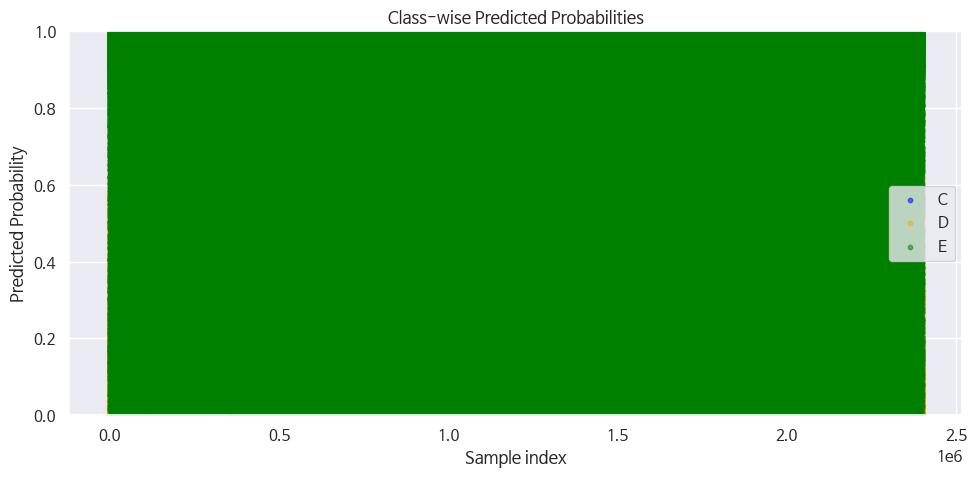

In [30]:
# 예측 결과에 대한 확률 값을 가져온다
y_proba = best_model.predict_proba(train_X)

plt.figure(figsize=(10, 5))

x = np.arange(len(y_proba))

plt.scatter(x - 0.2, y_proba[:, 0], label='C', alpha=0.5, s=10, color='blue')
plt.scatter(x,         y_proba[:, 1], label='D', alpha=0.5, s=10, color='orange')
plt.scatter(x + 0.2, y_proba[:, 2], label='E', alpha=0.5, s=10, color='green')

plt.xlabel('Sample index')
plt.ylabel('Predicted Probability')
plt.title('Class-wise Predicted Probabilities')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
10 / 0

In [ ]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

# 그리고 나서 train_X_sub를 가지고 GridSearchCV 수행


In [27]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
best_model.fit(train_X_sub, train_y_sub)
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
10/0

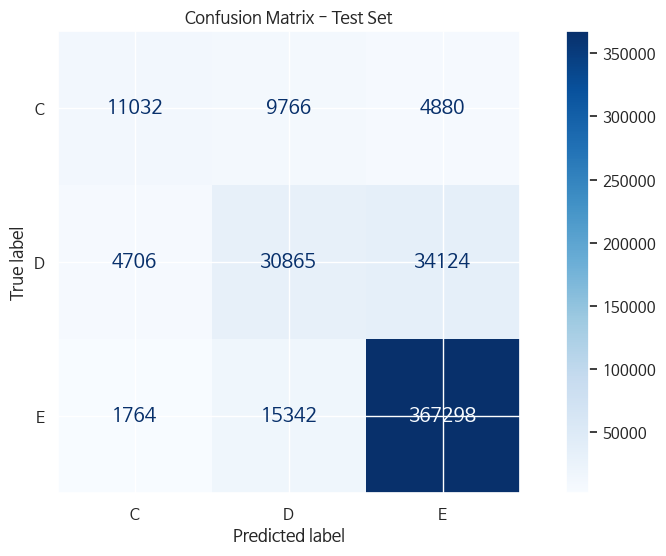

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화 (라벨 지정)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'D', 'E'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.show()


In [33]:
# 학습 모델 등을 저장한다.
with open(best_model_path, 'wb') as fp :

    # 인코더들
    pickle.dump(인입횟수_ARS_R6M인코더, fp)
    pickle.dump(방문횟수_앱_R6M인코더, fp)
    pickle.dump(방문횟수_PC_R6M인코더, fp)
    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)

print('저장완료')

저장완료
